In [4]:
# pip install librosa


In [5]:
audio_file ='taylor-swift-shake-it-off'

In [6]:
import librosa
import numpy as np

y, sr = librosa.load(audio_file +'.mp3', sr=None)


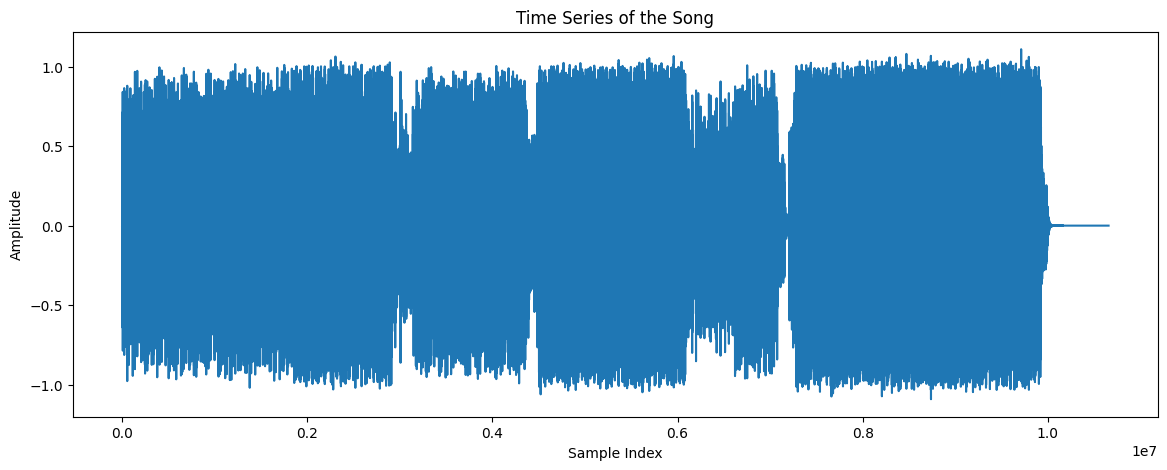

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y)
plt.title('Time Series of the Song')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

In [8]:
# pip install soundfile

In [9]:
import soundfile as sf

In [10]:
len(y)

10656768

In [11]:
sr

44100

In [12]:
import librosa
samples_in_1_min = sr * 60

# Chop the song to the first 1 minute
y_1_min = y[:samples_in_1_min]
print(f"Chopped the song to 1 minute. Total samples: {len(y_1_min)}")


Chopped the song to 1 minute. Total samples: 2646000


In [13]:
negative_values_exist = np.any(y_1_min < 0)
negative_values_exist

True

In [14]:
# Calculate the absolute value of the minimum value of the time series data
min_value_abs = np.abs(np.min(y))

# Add this value to the entire dataset
y_adjusted = y + min_value_abs

print(f"Absolute value of the minimum value: {min_value_abs}")
print(f"First 10 values of the adjusted dataset: {y_adjusted[:10]}")

Absolute value of the minimum value: 1.092116355895996
First 10 values of the adjusted dataset: [1.0921164 1.0921164 1.0921164 1.0921164 1.0921164 1.0921164 1.0921164
 1.0921164 1.0921164 1.0921164]


In [15]:
negative_values_exist = np.any(y_adjusted < 0)
negative_values_exist

False

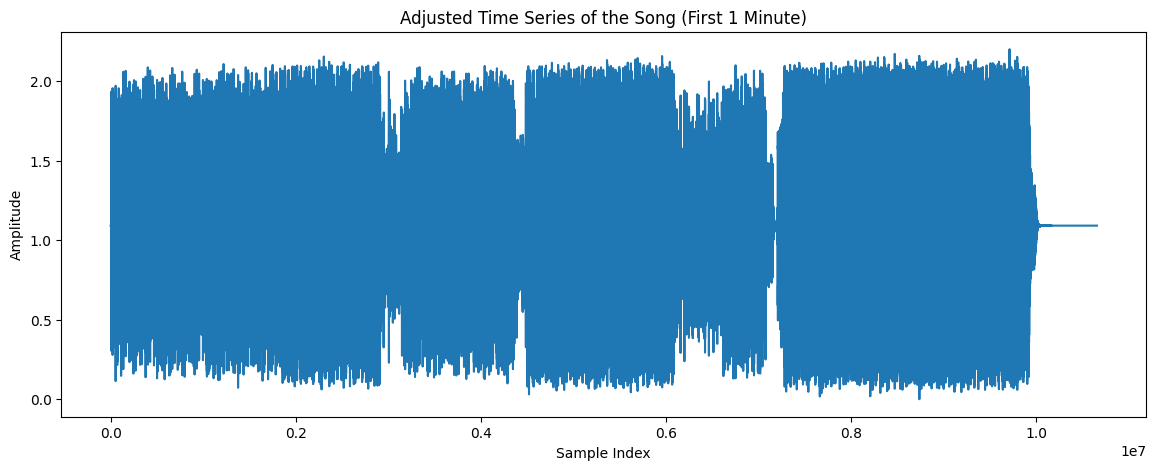

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(y_adjusted)
plt.title('Adjusted Time Series of the Song (First 1 Minute)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

In [17]:
# Compute STFT (Short-Time Fourier Transform)
stft_matrix = np.abs(librosa.stft(y_adjusted))

# Transpose to have time on rows, frequencies on columns
X = stft_matrix.T


In [18]:
X

array([[5.59709656e+02, 4.52978241e+02, 2.37316452e+02, ...,
        5.46060741e-01, 5.46058834e-01, 5.46058178e-01],
       [1.01700555e+03, 6.03912415e+02, 8.37110748e+01, ...,
        2.72611588e-01, 2.72610575e-01, 2.72610307e-01],
       [1.11833508e+03, 5.59159485e+02, 6.59079291e-03, ...,
        4.70616612e-08, 1.21204295e-07, 1.97807822e-07],
       ...,
       [1.11832715e+03, 5.59163574e+02, 1.32020800e-14, ...,
        1.82933113e-15, 5.68473220e-14, 0.00000000e+00],
       [1.01645947e+03, 6.03992859e+02, 8.40972061e+01, ...,
        2.73449183e-01, 2.73448229e-01, 2.73447901e-01],
       [5.58617493e+02, 4.52303741e+02, 2.37316452e+02, ...,
        5.46060741e-01, 5.46058834e-01, 5.46058178e-01]], dtype=float32)

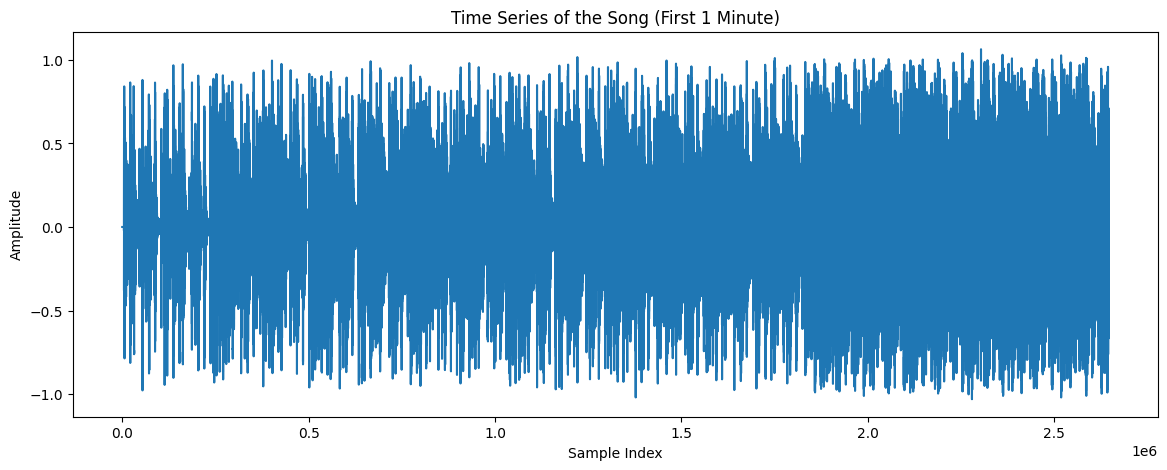

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_1_min)
plt.title('Time Series of the Song (First 1 Minute)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

In [20]:
X.shape

(20815, 1025)

In [21]:
from sklearn.decomposition import NMF

# Define the number of components (e.g., 10 components)
n_components = 50

# Apply NMF to the feature matrix
nmf_model = NMF(n_components=n_components, init='random', random_state=0)

# W: Basis matrix (components)
# H: Coefficient matrix (activations)
W = nmf_model.fit_transform(X)
H = nmf_model.components_

# W is the time-series representation in terms of components
# H represents the activations of those components


c:\Users\divya\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_nmf.py:1770: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [22]:
W.shape

(20815, 50)

In [23]:
H.shape

(50, 1025)

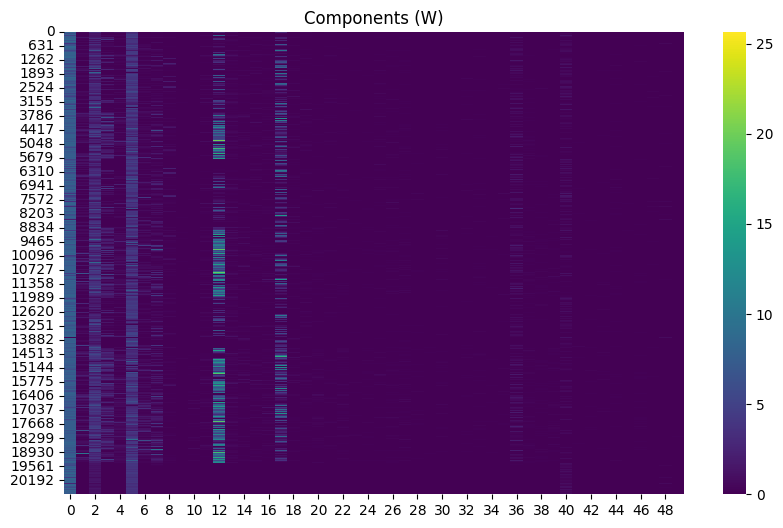

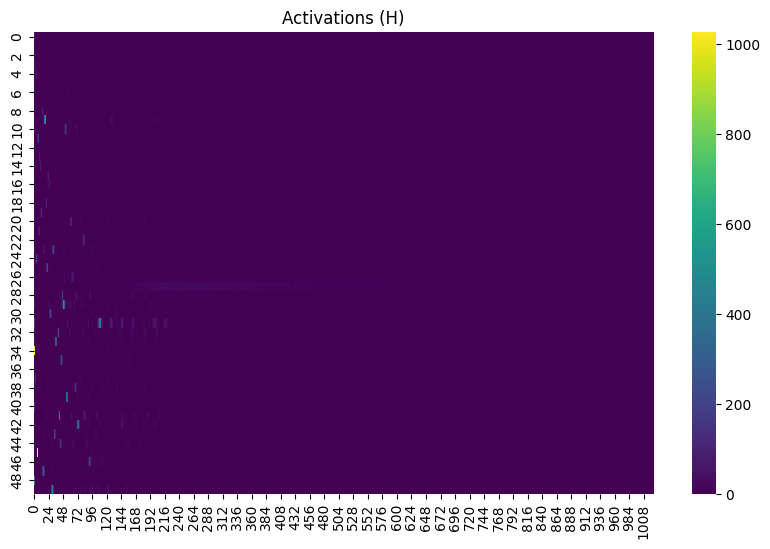

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the components (W)
plt.figure(figsize=(10, 6))
sns.heatmap(W, cmap='viridis')
plt.title('Components (W)')
plt.show()

# Plot the activations (H)
plt.figure(figsize=(10, 6))
sns.heatmap(H, cmap='viridis')
plt.title('Activations (H)')
plt.show()


In [25]:
# W and H are obtained from NMF
X_reconstructed = np.dot(W, H)

# Transpose back to the original STFT format (if necessary)
X_reconstructed = X_reconstructed.T


In [26]:


# Reconstruct the time-domain signal from the STFT matrix
y_reconstructed = librosa.istft(X_reconstructed)



In [27]:
# pip install ffmpeg

In [28]:
import librosa
import numpy as np
from pydub import AudioSegment
import ffmpeg

# Load the original song and reconstruct the time-domain signal from the NMF output
# Assuming y_reconstructed is obtained from librosa.istft()

# First, librosa gives you the waveform (y_reconstructed) in NumPy array format.
# You need to convert it to an audio segment using pydub

# Convert to 16-bit PCM format (required for saving as MP3)
y_reconstructed_16bit = np.int16(y_reconstructed / np.max(np.abs(y_reconstructed)) * 32767)

# Define sampling rate (should be the same as the original)
sr = 48000  # or whatever the sampling rate of the original song is

# Convert the NumPy array to an audio segment using pydub
audio_segment = AudioSegment(
    y_reconstructed_16bit.tobytes(), 
    frame_rate=sr,
    sample_width=2,  # 16-bit PCM is 2 bytes per sample
    channels=1       # Assuming mono audio, use 2 for stereo
)

# Save as MP3
# audio_segment.export("reconstructed_song.mp3", format="mp3")

sf.write(audio_file+'_reconstructed_50.mp3', y_reconstructed_16bit, sr)

print("Reconstructed audio saved as MP3!")


c:\Users\divya\AppData\Local\Programs\Python\Python311\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


Reconstructed audio saved as MP3!


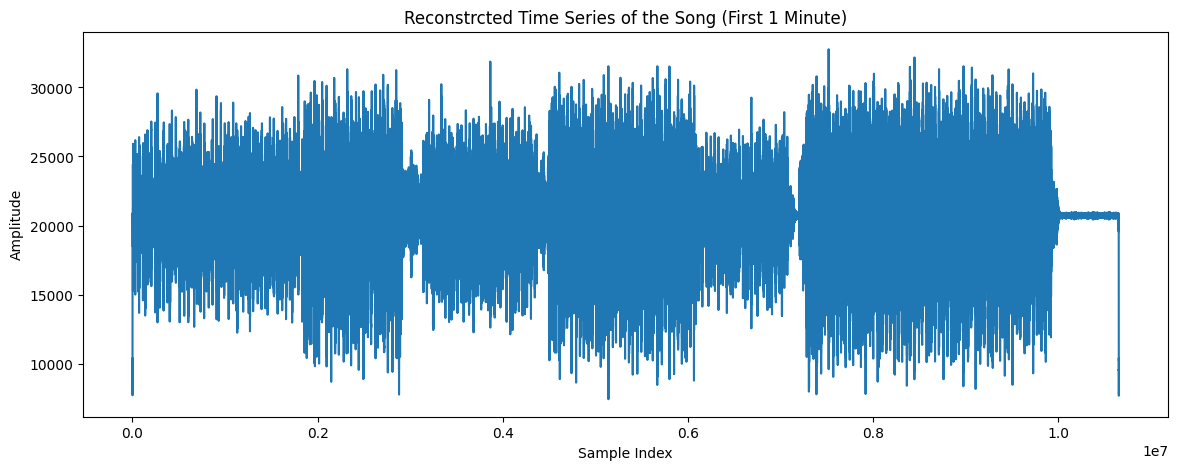

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(y_reconstructed_16bit)
plt.title('Reconstrcted Time Series of the Song (First 1 Minute)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

In [30]:
from scipy.linalg import svd

# # Compute SVD
# U, S, Vt = svd(stft_matrix, full_matrices=False)

# # Reconstruct the STFT matrix using the SVD components
# S_matrix = np.diag(S)
# X_svd_reconstructed = np.dot(U, np.dot(S_matrix, Vt))

# # Reconstruct the time-domain signal from the reconstructed STFT matrix
# y_svd_reconstructed = librosa.istft(X_svd_reconstructed)
# Reconstruct the STFT matrix using a lower rank approximation
rank = 50  # Define the lower rank
U_reduced = U[:, :rank]
S_reduced = S[:rank]
Vt_reduced = Vt[:rank, :]

# Reconstruct the STFT matrix using the reduced rank approximation
S_matrix_reduced = np.diag(S_reduced)
X_svd_reconstructed_reduced = np.dot(U_reduced, np.dot(S_matrix_reduced, Vt_reduced))

# Reconstruct the time-domain signal from the reduced rank STFT matrix
y_svd_reconstructed_reduced = librosa.istft(X_svd_reconstructed_reduced)

# Convert to 16-bit PCM format (required for saving as MP3)
y_svd_reconstructed_reduced_16bit = np.int16(y_svd_reconstructed_reduced / np.max(np.abs(y_svd_reconstructed_reduced)) * 32767)

# Save the reconstructed audio
sf.write(audio_file + '_svd_reconstructed_reduced_rank.mp3', y_svd_reconstructed_reduced_16bit, sr)

print("SVD reconstructed audio with reduced rank saved as MP3!")

NameError: name 'U' is not defined

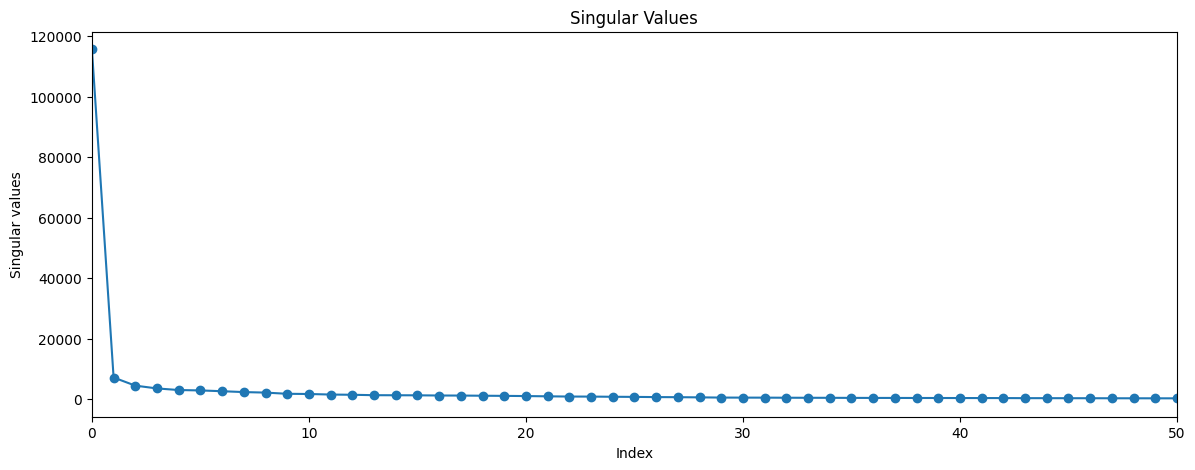

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(S, marker='o')
plt.xlim(0, 50)
plt.title('Singular Values')
plt.xlabel('Index')
plt.ylabel('Singular values')
plt.show()

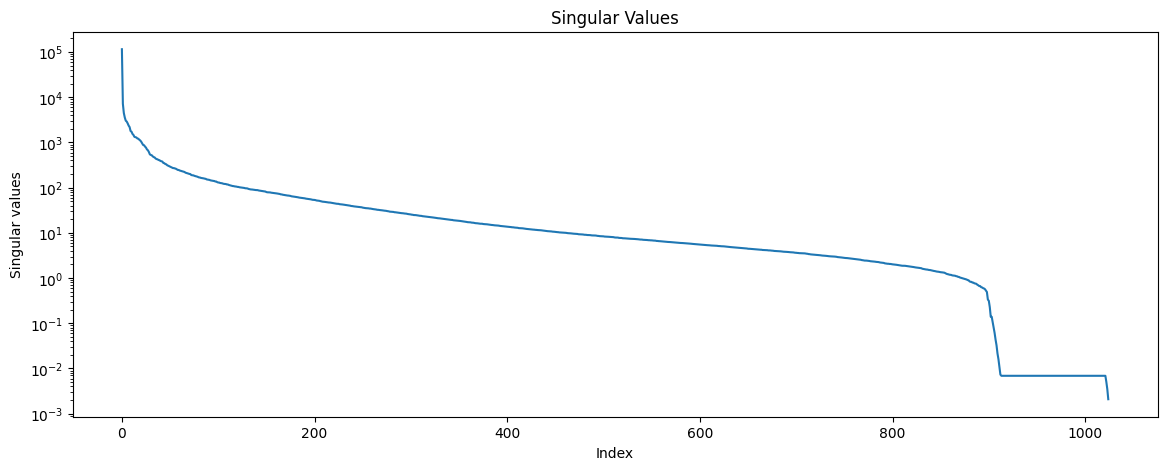

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(S)
plt.yscale('log')
plt.title('Singular Values')
plt.xlabel('Index')
plt.ylabel('Singular values')
plt.show()

In [34]:
pip install gtts

Note: you may need to restart the kernel to use updated packages.Collecting gtts



In [35]:
import pytesseract
from PIL import Image
from gtts import gTTS

image = Image.open('halloween-pumpkins-royalty-free-image-1686938575.jpg')
text = pytesseract.image_to_string(image)

tts = gTTS(text)
tts.save("output.mp3")

TesseractNotFoundError: tesseract is not installed or it's not in your PATH. See README file for more information.